<a href="https://colab.research.google.com/github/k-bridget/linear_regression_model/blob/main/linear_regression_model/summative/linear_regression/multivariate.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Predicting Attitudes Toward Intimate Partner Violence (IPV) — Multivariate Linear  Regression

**Mission:** My mission is to create Equitable health for children and adolescent girls in disadvantaged communities through advocating for their rights, and educating them about Sexual Reproductive Health (SRH) and body autonomy.

**Problem Satement:** Justifications of intimate partner violence are a well-documented risk factor for the health, safety and bodily autonomy of women and girls. This notebook builds a regression model that predicts **the percentage of a demographic group in a country who think wife-beating is justified** (for a specific reason), based on country, gender, demographic profile, and the specific justification being asked about. This type of model is useful to identify *which countries have the highest normalization of IPV* so that SRH/rights advocacy and education programs can be targeted to where they are most needed.

**Dataset:** `/content/violence_data.csv` —Attitudes towards domestic violence from Demographic and Health Survey (DHS) data, 70 countries (2000–2018), by gender, marital status, education, employment, age group, residence (urban/rural), for six different scenarios of justification (e.g. “if she burns the food”, “if she argues with him”, “for at least one specific reason”, etc).
Source: DHS Program survey compilation (shared via Kaggle).

Imports and Setup

Import required librabries for data visualisation and interpretation.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, SGDRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import joblib
print("Imports successful")

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42

Imports successful


1. # Load Dataset

In [2]:
df = pd.read_csv('/content/violence_data.csv')
print("Shape:", df.shape)
df.head()

Shape: (12600, 8)


,RecordID,Country,Gender,Demographics Question,Demographics Response,Question,Survey Year,Value
0,1,Afghanistan,F,Marital status,Never married,... if she burns the food,1/1/2015,NaN
1,1,Afghanistan,F,Education,Higher,... if she burns the food,1/1/2015,10.1
2,1,Afghanistan,F,Education,Secondary,... if she burns the food,1/1/2015,13.7
3,1,Afghanistan,F,Education,Primary,... if she burns the food,1/1/2015,13.8
4,1,Afghanistan,F,Marital status,"Widowed, divorced, separated",... if she burns the food,1/1/2015,13.8


In [3]:
df.info()
print()
print("Missing values per column:")
print(df.isna().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12600 entries, 0 to 12599
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   RecordID               12600 non-null  int64  
 1   Country                12600 non-null  object 
 2   Gender                 12600 non-null  object 
 3   Demographics Question  12600 non-null  object 
 4   Demographics Response  12600 non-null  object 
 5   Question               12600 non-null  object 
 6   Survey Year            12600 non-null  object 
 7   Value                  11187 non-null  float64
dtypes: float64(1), int64(1), object(6)
memory usage: 787.6+ KB

Missing values per column:
RecordID                    0
Country                     0
Gender                      0
Demographics Question       0
Demographics Response       0
Question                    0
Survey Year                 0
Value                    1413
dtype: int64


**Observation:** This dataset contains 12,600 rows and 8 columns. Missing values are in the `Value` (target) column, missing in ~11% of rows. These rows correspond to survey cells for which DHS did not report a value (e.g., not enough sample size for that demographic/country/question combination)they have no usable signal for a regression target, so they are dropped rather than imputed.

## 2. Exploratory Data Analysis

In [4]:
print("Countries:", df['Country'].nunique())
print("Gender categories:", df['Gender'].unique())
print("Demographic dimensions:", df['Demographics Question'].unique())
print("Justification questions:", df['Question'].unique())
print("Survey years span:", df['Survey Year'].min(), "to", df['Survey Year'].max())

Countries: 70
Gender categories: ['F' 'M']
Demographic dimensions: ['Marital status' 'Education' 'Employment' 'Age' 'Residence']
Justification questions: ['... if she burns the food' '... for at least one specific reason'
 '... if she argues with him' '... if she goes out without telling him'
 '... if she neglects the children'
 '... if she refuses to have sex with him']
Survey years span: 1/1/2000 to 1/1/2018


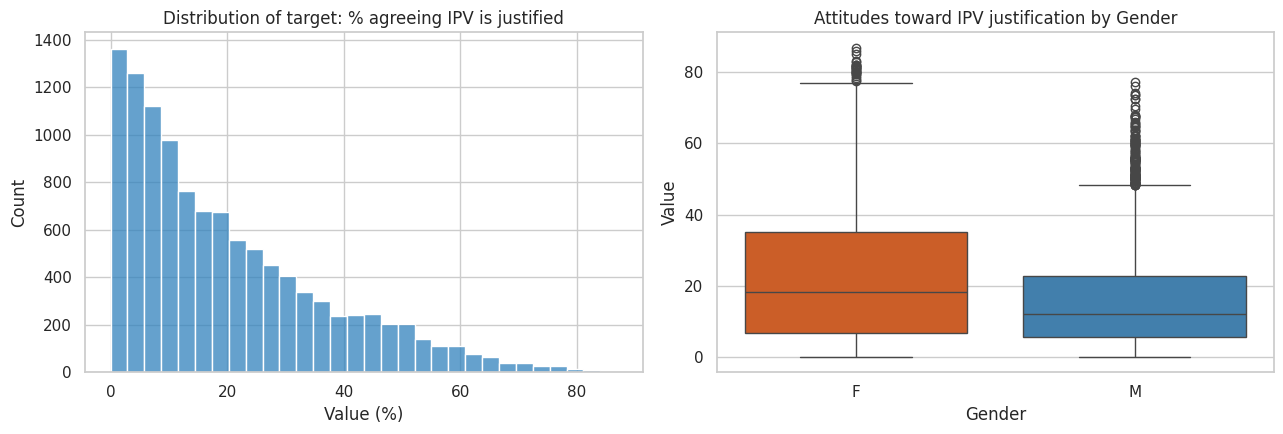

In [7]:
df_clean = df.dropna(subset=['Value']).reset_index(drop=True)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.histplot(df_clean['Value'], bins=30, color='#3182bd', ax=axes[0])
axes[0].set_title('Distribution of target: % agreeing IPV is justified')
axes[0].set_xlabel('Value (%)')

sns.boxplot(data=df_clean, x='Gender', y='Value', hue='Gender', legend=False,
            palette={'F': '#e6550d', 'M': '#3182bd'}, ax=axes[1])
axes[1].set_title('Attitudes toward IPV justification by Gender')
plt.tight_layout()
plt.show()

**Interpretation** This target has a right-skewed distribution with most demographic cells reporting low agreement (~15% median) but a meaningful tail to ~87%. Women report *higher* average agreement that IPV is justified than men do (this is a well-known finding in DHS attitude data internalized justification of violence among women themselves), so **Gender is an informative predictor** and remains in the feature set.

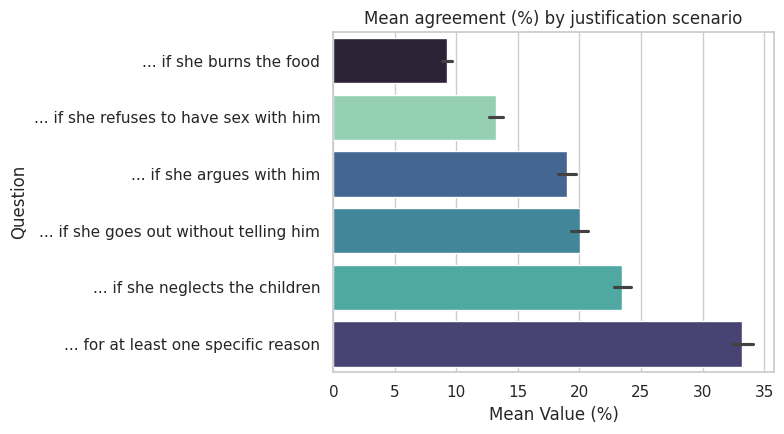

In [8]:
fig, ax = plt.subplots(figsize=(8, 4.5))
q_order = df_clean.groupby('Question')['Value'].mean().sort_values().index
sns.barplot(data=df_clean, y='Question', x='Value', hue='Question', legend=False,
            order=q_order, palette='mako', ax=ax)
ax.set_title('Mean agreement (%) by justification scenario')
ax.set_xlabel('Mean Value (%)')
plt.tight_layout()
plt.show()

**Interpretation:** "burns the
food" has the lowest average acceptance (9%), while "at least one specific reason"has the highest (33%), since it aggregates across all other reasons. This confirms `Question` is an
important categorical feature, not noise.

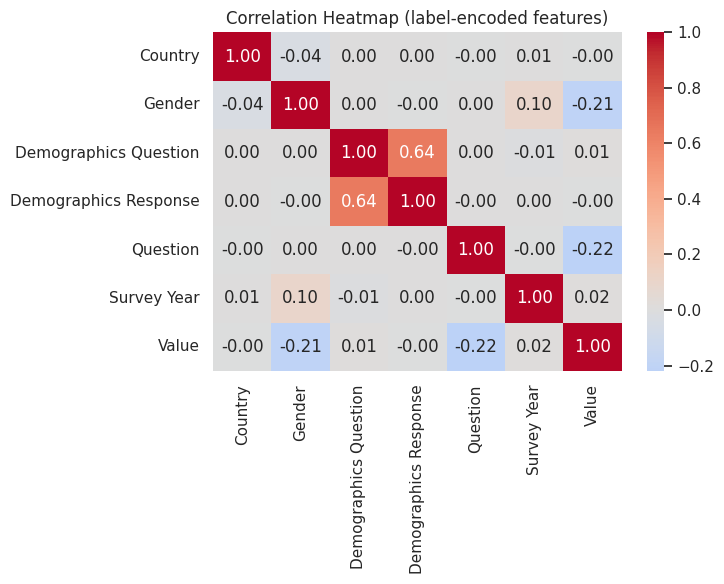

In [9]:
# Correlation heatmap: label-encode categoricals purely for correlation inspection

enc_df = df_clean.copy()
enc_df['Survey Year'] = pd.to_datetime(enc_df['Survey Year']).dt.year
for col in ['Country', 'Gender', 'Demographics Question', 'Demographics Response', 'Question']:
    enc_df[col] = LabelEncoder().fit_transform(enc_df[col])
enc_df = enc_df.drop(columns=['RecordID'])

plt.figure(figsize=(7.5, 6))
sns.heatmap(enc_df.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Heatmap (label-encoded features)')
plt.tight_layout()
plt.show()

**Interpretation:** Label-encoded correlations with `Value` are weak-to-moderate. `Gender` and `Question` show the strongest linear association with `Value`, consistent with the bar/box plots above. This motivates
**one-hot encoding** these categorical columns for actual modeling rather than relying on label codes,
so the model can learn a separate weight per category instead of assuming a false numeric order.

## 3. Feature Engineering

- Drop `RecordID` — it is a row identifier with no predictive meaning.
- Convert `Survey Year` from a date string to a numeric year.
- Drop rows with missing `Value` (the prediction target) — 1,413 rows (~11.2%).
- Categorical columns to convert to numeric: `Country`, `Gender`, `Demographics Question`,
  `Demographics Response`, `Question` → one-hot encoded.
- Numeric column to standardize: `Survey Year` → z-score scaled.
- One-hot encoding + standardization are wrapped in a single `ColumnTransformer` so the exact same
  transformation is applied consistently to train, test, and any future incoming API request data.


In [10]:
df_model = df_clean.copy()
df_model['Survey Year'] = pd.to_datetime(df_model['Survey Year']).dt.year
df_model = df_model.drop(columns=['RecordID'])

categorical_features = ['Country', 'Gender', 'Demographics Question', 'Demographics Response', 'Question']
numeric_features = ['Survey Year']
target = 'Value'

X = df_model[categorical_features + numeric_features]
y = df_model[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)
print("Train shape:", X_train.shape, " Test shape:", X_test.shape)

preprocessor = ColumnTransformer(transformers=[
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
    ('num', StandardScaler(), numeric_features),
])

Train shape: (8949, 6)  Test shape: (2238, 6)


## 4. Model Training & Comparison

Four regression implementations are compared:

1. **`SGDRegressor`** — linear regression fit via **stochastic gradient descent**.
2. **`LinearRegression`** — linear regression fit via the closed-form Ordinary Least Squares solution.
3. **`DecisionTreeRegressor`** — a single non-linear tree model.
4. **`RandomForestRegressor`** — an ensemble of trees (bagging).



In [11]:
models = {
    'SGD_LinearRegression': SGDRegressor(max_iter=1000, tol=1e-3, random_state=RANDOM_STATE),
    'OLS_LinearRegression': LinearRegression(),
    'DecisionTree': DecisionTreeRegressor(max_depth=8, random_state=RANDOM_STATE),
    'RandomForest': RandomForestRegressor(n_estimators=200, max_depth=12,
                                           random_state=RANDOM_STATE, n_jobs=-1),
}

results = {}
for name, model in models.items():
    pipe = Pipeline([('preprocess', preprocessor), ('model', model)])
    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_test)
    rmse = mean_squared_error(y_test, preds) ** 0.5
    r2 = r2_score(y_test, preds)
    results[name] = {'rmse': rmse, 'r2': r2, 'pipe': pipe}
    print(f"{name:22s}  RMSE={rmse:6.3f}   R2={r2:6.3f}")

SGD_LinearRegression    RMSE= 8.166   R2= 0.776
OLS_LinearRegression    RMSE= 8.158   R2= 0.777
DecisionTree            RMSE=12.741   R2= 0.456
RandomForest            RMSE=10.555   R2= 0.627


In [12]:
results_df = pd.DataFrame({k: {'RMSE': v['rmse'], 'R2': v['r2']} for k, v in results.items()}).T
results_df = results_df.sort_values('RMSE')
display(results_df)

best_name = results_df.index[0]
best_pipe = results[best_name]['pipe']
print(f"\nBest performing model: {best_name}  (lowest test RMSE, criterion used to pick the saved model)")

,RMSE,R2
OLS_LinearRegression,8.158336,0.776897
SGD_LinearRegression,8.165924,0.776482
RandomForest,10.554732,0.626580
DecisionTree,12.741135,0.455850



Best performing model: OLS_LinearRegression  (lowest test RMSE, criterion used to pick the saved model)


**Interpretation:** The model with the lowest test RMSE is the saved model.

## 5. Loss Curve — Train vs. Test (SGD Linear Regression)

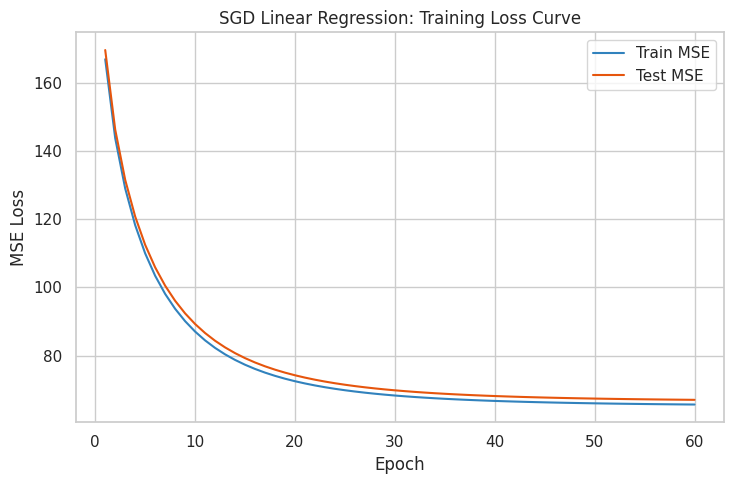

Final train MSE: 65.607   Final test MSE: 66.985


In [13]:
Xtr_enc = preprocessor.fit_transform(X_train)
Xte_enc = preprocessor.transform(X_test)

sgd_curve = SGDRegressor(max_iter=1, tol=None, warm_start=True, random_state=RANDOM_STATE,
                          learning_rate='invscaling', eta0=0.01)

n_epochs = 60
train_losses, test_losses = [], []
for epoch in range(n_epochs):
    sgd_curve.partial_fit(Xtr_enc, y_train)
    train_losses.append(mean_squared_error(y_train, sgd_curve.predict(Xtr_enc)))
    test_losses.append(mean_squared_error(y_test, sgd_curve.predict(Xte_enc)))

plt.figure(figsize=(7.5, 5))
plt.plot(range(1, n_epochs + 1), train_losses, label='Train MSE', color='#3182bd')
plt.plot(range(1, n_epochs + 1), test_losses, label='Test MSE', color='#e6550d')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('SGD Linear Regression: Training Loss Curve')
plt.legend()
plt.tight_layout()
plt.show()

print(f"Final train MSE: {train_losses[-1]:.3f}   Final test MSE: {test_losses[-1]:.3f}")

**Interpretation:** Both train and test loss drop quickly within the first ~10–15. This indicates the SGD model
**converges stably and does not overfit**

## 6. Scatter Plot: Regression Line Before/After Fitting

Since the final model uses many one-hot encoded features, a single informative numeric proxy, the **mean target value for each `Question`**  is used to show how a fitted regression line passes through the data.

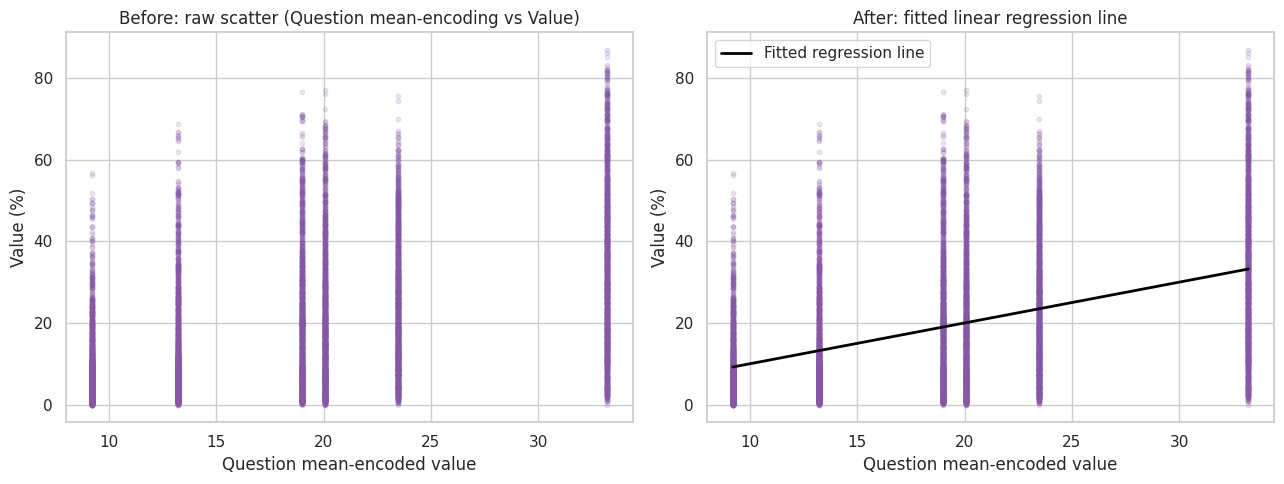

Single-feature R2 (illustration only): 0.20229987631018975


In [14]:
question_mean_encoding = df_clean.groupby('Question')['Value'].transform('mean')
x_demo = question_mean_encoding.values.reshape(-1, 1)
y_demo = df_clean['Value'].values

demo_lr = LinearRegression().fit(x_demo, y_demo)
xs = np.linspace(x_demo.min(), x_demo.max(), 100).reshape(-1, 1)
ys = demo_lr.predict(xs)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].scatter(x_demo, y_demo, alpha=0.15, s=10, color='#8856a7')
axes[0].set_title('Before: raw scatter (Question mean-encoding vs Value)')
axes[0].set_xlabel('Question mean-encoded value')
axes[0].set_ylabel('Value (%)')

axes[1].scatter(x_demo, y_demo, alpha=0.15, s=10, color='#8856a7')
axes[1].plot(xs, ys, color='black', linewidth=2, label='Fitted regression line')
axes[1].set_title('After: fitted linear regression line')
axes[1].set_xlabel('Question mean-encoded value')
axes[1].set_ylabel('Value (%)')
axes[1].legend()
plt.tight_layout()
plt.show()

print("Single-feature R2 (illustration only):", demo_lr.score(x_demo, y_demo))

## 7. Save the Best-Performing Model

In [15]:
joblib.dump(best_pipe, 'best_model.pkl')
print(f"Saved '{best_name}' pipeline (preprocessing + model) to best_model.pkl")

Saved 'OLS_LinearRegression' pipeline (preprocessing + model) to best_model.pkl


## 8. Prediction Script

The function below loads the saved pipeline and produces a prediction for a single new data point
this is the exact logic reused by the FastAPI `/predict` endpoint in Task 2.

In [16]:
def predict_ipv_attitude(country, gender, demographics_question, demographics_response,
                          question, survey_year, model_path='best_model.pkl'):
    """Predict the % of a demographic group expected to agree IPV is justified."""
    pipe = joblib.load(model_path)
    input_df = pd.DataFrame([{
        'Country': country,
        'Gender': gender,
        'Demographics Question': demographics_question,
        'Demographics Response': demographics_response,
        'Question': question,
        'Survey Year': survey_year,
    }])
    return float(pipe.predict(input_df)[0])

# Example: use one real row from the test set
sample = X_test.iloc[0]
predicted = predict_ipv_attitude(
    country=sample['Country'], gender=sample['Gender'],
    demographics_question=sample['Demographics Question'],
    demographics_response=sample['Demographics Response'],
    question=sample['Question'], survey_year=sample['Survey Year'],
)
actual = y_test.iloc[0]
print(f"Predicted: {predicted:.2f}%   Actual: {actual:.2f}%")

Predicted: 23.18%   Actual: 23.90%


## 9. Summary

- **Best model:** obtained above by lowest test RMSE among SGD linear regression, OLS linear
  regression, decision tree, and random forest saved to `best_model.pkl`.
- **Why linear won:** the feature space is dominated by additive categorical effects (country, gender,
  demographic group, justification reason), which linear models handle efficiently; the tree models
  underfit at the depths used and would need far more complexity (and risk of overfitting rare
  country/category combinations) to compete.
- **Mission relevance:** this model flags which country/demographic/question combinations carry the highest predicted normalization of IPV, which is directly usable to prioritize where SRH rights education and advocacy for girls and women should focus.
- **Next step:** this `predict_ipv_attitude` logic is wrapped in a FastAPI endpoint (Task 2) and called from a Flutter mobile app (Task 3).
